In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/womens-ecommerce-clothing-reviews/Womens Clothing E-Commerce Reviews.csv


# Gerekli kütüphaneleri import et****

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.exceptions import ConvergenceWarning
import random

In [3]:
# Uyarıları kapatma
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter("ignore", category=ConvergenceWarning)


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', 500)

In [4]:
df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")

# Veriye rastgele eksik değer ekler****

In [5]:
def add_random_missing_values(dataframe: pd.DataFrame,
                              missing_rate: float = 0.05) -> pd.DataFrame:
    """Turns random values to NaN in a DataFrame.

    To use this function, you need to import pandas, numpy and random libraries.

    Args:
        dataframe (pd.DataFrame): DataFrame to be processed.
        missing_rate (float): Percentage of missing value rate in float format. Defaults 0.05

    Returns:
        df_missing (pd.DataFrame): Processed DataFrame object.

    """
    # Get copy of dataframe
    df_missing = dataframe.copy()

    # Obtain size of dataframe and number total number of missing values
    df_size = dataframe.size
    num_missing = int(df_size * missing_rate)

    # Get random row and column indexes to turn them NaN
    for _ in range(num_missing):
        row_idx = random.randint(0, dataframe.shape[0] - 1)
        col_idx = random.randint(0, dataframe.shape[1] - 1)

        df_missing.iat[row_idx, col_idx] = np.nan

    return df_missing

df_missing = add_random_missing_values(df)

df.isnull().sum().sum()
df_missing.isnull().sum().sum()

df = df_missing

# ****Benzersiz değerleri ve sayısını yazdırır

Unnamed: 0 ve Title gibi sütunlar öneri sistemi için anlamlı bilgi sağlamaz, bu nedenle çıkarılabilir.
Clothing ID, Rating, ve Review Text sütunları öneriler için anahtar bilgilerdir. Kullanıcıların değerlendirmeleri ve ürün detayları modele doğrudan katkı sağlar.
Eksik veriler (NaN değerleri) temizlenmeli veya uygun yöntemlerle doldurulmalıdır.


In [6]:
def unique_values(dataframe):

    for col in df.columns:
        unique_values = df[col].unique()  # Sütundaki benzersiz değerleri alır
        print(f"{col} sütununun benzersiz değerleri:{df[col].nunique()}")
        print(unique_values)
        print("\n" + "#" * 50 + "\n")  # Her sütunun sonunda ayırıcı ekler

unique_values(df)


Unnamed: 0 sütununun benzersiz değerleri:22313
[0.0000e+00 1.0000e+00 2.0000e+00 ... 2.3483e+04 2.3484e+04 2.3485e+04]

##################################################

Clothing ID sütununun benzersiz değerleri:1191
[ 767. 1080. 1077. ...  721.  262.  522.]

##################################################

Age sütununun benzersiz değerleri:77
[33. 34. 60. 50. 47. 49. 39. 24. 53. 44. 41. 32. 55. 31. 28. nan 46. 21.
 36. 65. 29. 38. 59. 40. 23. 67. 48. 43. 52. 56. 61. 57. 58. 37. 27. 62.
 68. 51. 83. 69. 66. 63. 71. 30. 35. 64. 42. 54. 22. 26. 72. 25. 45. 74.
 70. 20. 80. 93. 82. 77. 85. 73. 78. 79. 76. 84. 75. 89. 19. 81. 90. 94.
 86. 99. 18. 91. 87. 92.]

##################################################

Title sütununun benzersiz değerleri:13387
[nan 'Some major design flaws' 'My favorite buy!' ...
 'Cute, but see through'
 'Very cute dress, perfect for summer parties and we'
 'Please make more like this one!']

##################################################

Review Text sü

# Genel veri tipi, istatistik ve eksik değer yüzdelerini görüntüle****

Veri seti 23.486 satır ve 11 sütundan oluşuyor, ancak bazı sütunlarda eksik veriler dikkat çekiyor. Özellikle Title sütununda %20,36 ve Review Text sütununda %8,24 oranında eksik veri bulunuyor. Sayısal verilere baktığımızda, kullanıcı yaşlarının genellikle 34-52 arasında yoğunlaştığını, ürünlerin çoğunlukla yüksek puanlar aldığını ve pozitif geri bildirimlerin düşük seviyelerde olduğunu görüyoruz.

In [7]:

print(df.info())  # Veri tipi ve eksik değerleri görme
print(df.describe())  # Sayısal sütunlar için özet istatistikler
print(df.isnull().sum() / len(df) * 100)  # Eksik değer yüzdelerini inceleme

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               22313 non-null  float64
 1   Clothing ID              22345 non-null  float64
 2   Age                      22335 non-null  float64
 3   Title                    18738 non-null  object 
 4   Review Text              21534 non-null  object 
 5   Rating                   22360 non-null  float64
 6   Recommended IND          22299 non-null  float64
 7   Positive Feedback Count  22315 non-null  float64
 8   Division Name            22375 non-null  object 
 9   Department Name          22293 non-null  object 
 10  Class Name               22365 non-null  object 
dtypes: float64(6), object(5)
memory usage: 2.0+ MB
None
       Unnamed: 0  Clothing ID       Age    Rating  Recommended IND  Positive Feedback Count
count   22313.000    22345.000 22335.00

# ****Veri seti ile ilgili temel bilgileri yazdırır

Quantiles => Veri setindeki yüzde dilimleri, Age ve Positive Feedback Count gibi değişkenlerde geniş bir aralık olduğunu, özellikle Rating ve Recommended IND değişkenlerinde ise değerlerin üst sınırda yoğunlaştığını göstermektedir.

In [8]:
def check_df(dataframe, head=5):
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Types #####################")
    print(dataframe.dtypes)
    print("##################### Head #####################")
    print(dataframe.head(head))
    print("##################### Tail #####################")
    print(dataframe.tail(head))
    print("##################### NA #####################")
    print(dataframe.isnull().sum())
    float_columns = dataframe.select_dtypes(include=['float64'])
    print("##################### Quantiles #####################")
    print(float_columns.quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T)

check_df(df)


##################### Shape #####################
(23486, 11)
##################### Types #####################
Unnamed: 0                 float64
Clothing ID                float64
Age                        float64
Title                       object
Review Text                 object
Rating                     float64
Recommended IND            float64
Positive Feedback Count    float64
Division Name               object
Department Name             object
Class Name                  object
dtype: object
##################### Head #####################
   Unnamed: 0  Clothing ID    Age                    Title                                        Review Text  Rating  Recommended IND  Positive Feedback Count   Division Name Department Name Class Name
0       0.000      767.000 33.000                      NaN  Absolutely wonderful - silky and sexy and comf...   4.000            1.000                    0.000             NaN        Intimate  Intimates
1       1.000     1080.000 34.000 

# ****Kategorik ve sayısal sütunları gruplandırır

Veri setinde 23.486 gözlem ve 11 değişken bulunurken, 5 kategorik, 4 sayısal, 2 metinsel ve 2 sayısal ama kategorik özellik taşıyan sütun bulunmaktadır.

In [9]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """

    Veri setindeki kategorik, numerik ve kategorik fakat kardinal değişkenlerin isimlerini verir.
    Not: Kategorik değişkenlerin içerisine numerik görünümlü kategorik değişkenler de dahildir.

    Parameters
    ------
        dataframe: dataframe
                Değişken isimleri alınmak istenilen dataframe
        cat_th: int, optional
                numerik fakat kategorik olan değişkenler için sınıf eşik değeri
        car_th: int, optinal
                kategorik fakat kardinal değişkenler için sınıf eşik değeri

    Returns
    ------
        cat_cols: list
                Kategorik değişken listesi
        num_cols: list
                Numerik değişken listesi
        cat_but_car: list
                Kategorik görünümlü kardinal değişken listesi

    Examples
    ------
        import seaborn as sns
        df = sns.load_dataset("iris")
        print(grab_col_names(df))


    Notes
    ------
        cat_cols + num_cols + cat_but_car = toplam değişken sayısı
        num_but_cat cat_cols'un içerisinde.
        Return olan 3 liste toplamı toplam değişken sayısına eşittir: cat_cols + num_cols + cat_but_car = değişken sayısı

    """

    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)} {cat_cols}')
    print(f'num_cols: {len(num_cols)} {num_cols}')
    print(f'cat_but_car: {len(cat_but_car)} {cat_but_car}')
    print(f'num_but_cat: {len(num_but_cat)} {num_but_cat}')
    return cat_cols, num_cols, cat_but_car

cat_cols, num_cols, cat_but_car = grab_col_names(df)


Observations: 23486
Variables: 11
cat_cols: 5 ['Division Name', 'Department Name', 'Class Name', 'Rating', 'Recommended IND']
num_cols: 4 ['Unnamed: 0', 'Clothing ID', 'Age', 'Positive Feedback Count']
cat_but_car: 2 ['Title', 'Review Text']
num_but_cat: 2 ['Rating', 'Recommended IND']


# DEĞİŞKENLERİN ANALİZİ

In [10]:
# KATEGORİK DEĞİŞKENLERİN ANALİZİ
def cat_summary(dataframe, col_names, plot=False):

    if not isinstance(col_names, list):
        col_names = [col_names]


    for col_name in col_names:
        print(f"Analiz edilen sütun: {col_name}")
        print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                            "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
        print("##########################################")
        if plot:
            sns.countplot(x=dataframe[col_name], data=dataframe)
            plt.title(f"{col_name} için Frekans Grafiği")
            plt.show(block = True)

cat_summary(df, cat_cols, plot=False)


Analiz edilen sütun: Division Name
                Division Name  Ratio
Division Name                       
General                 13193 56.174
General Petite           7741 32.960
Initmates                1441  6.136
##########################################
Analiz edilen sütun: Department Name
                 Department Name  Ratio
Department Name                        
Tops                        9955 42.387
Dresses                     5981 25.466
Bottoms                     3620 15.413
Intimate                    1637  6.970
Jackets                      987  4.203
Trend                        113  0.481
##########################################
Analiz edilen sütun: Class Name
                Class Name  Ratio
Class Name                       
Dresses               6042 25.726
Knits                 4589 19.539
Blouses               2958 12.595
Sweaters              1356  5.774
Pants                 1319  5.616
Jeans                 1108  4.718
Fine gauge            1040  4.428

# NUMERİK DEĞİŞKENLERİN ANALİZİ

Unnamed: 0: Bu sütun rastgele bir indeks gibi görünüyor ve anlamlı bir bilgi taşımadığı için analizlerde kullanılmayabilir.

Clothing ID: Ürün kimlikleri eşit dağılmamış; bazı ürünler çok fazla değerlendirilmişken, bazıları oldukça az değerlendirilmiş. Bu durum öneri sisteminde dikkate alınabilir.

Age: Kullanıcı yaşları genellikle 30-50 arasında yoğunlaşmış, ancak 80 yaş üstü kullanıcı sayısı oldukça az, bu da analizlerde sınırlı veri anlamına geliyor.

Positive Feedback Count: Pozitif geri bildirimlerin çoğu 0-5 arasında yoğunlaşmış, ancak 20'nin üzerindeki yüksek değerler aykırı olarak dikkat çekiyor ve modele olumsuz etkisi olabilir.

count   22313.000
mean    11762.736
std      6782.416
min         0.000
5%       1167.600
10%      2338.200
20%      4707.400
30%      7071.600
40%      9438.800
50%     11787.000
60%     14124.200
70%     16466.400
80%     18806.600
90%     21144.800
95%     22314.400
99%     23247.880
max     23485.000
Name: Unnamed: 0, dtype: float64


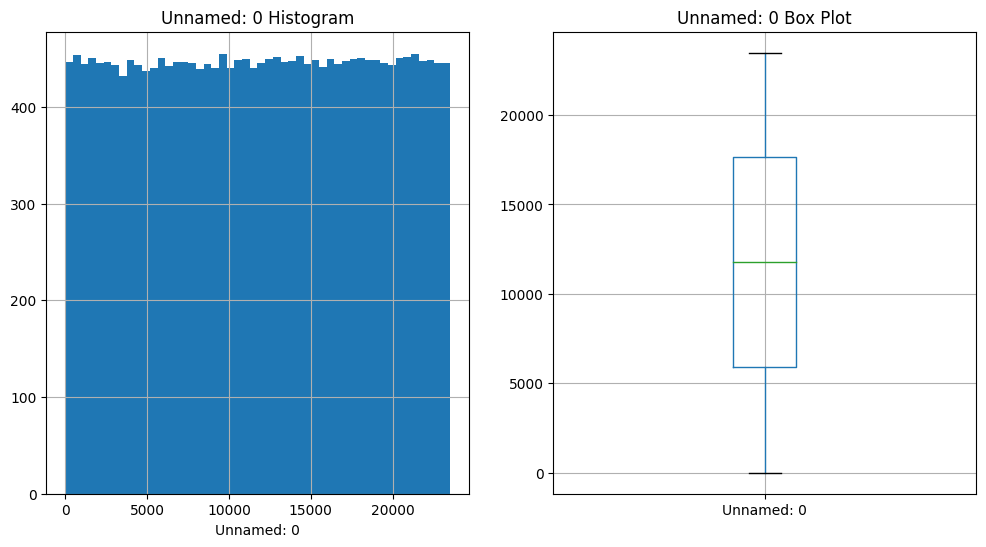

count   22345.000
mean      917.966
std       204.057
min         0.000
5%        412.200
10%       819.000
20%       839.000
30%       863.000
40%       876.000
50%       936.000
60%      1020.000
70%      1065.000
80%      1081.000
90%      1094.000
95%      1104.000
99%      1133.000
max      1205.000
Name: Clothing ID, dtype: float64


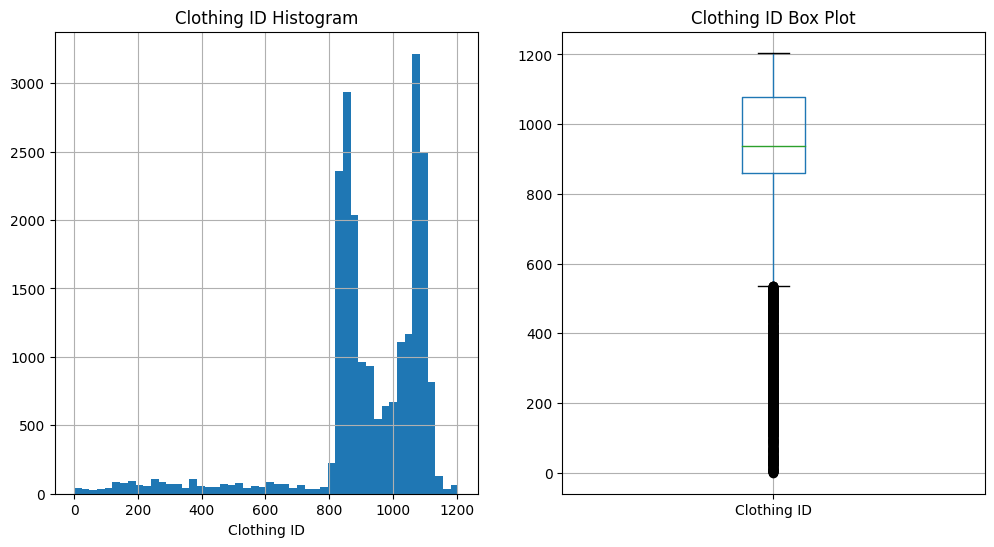

count   22335.000
mean       43.189
std        12.285
min        18.000
5%         25.000
10%        28.000
20%        33.000
30%        36.000
40%        39.000
50%        41.000
60%        45.000
70%        49.000
80%        54.000
90%        61.000
95%        65.000
99%        74.000
max        99.000
Name: Age, dtype: float64


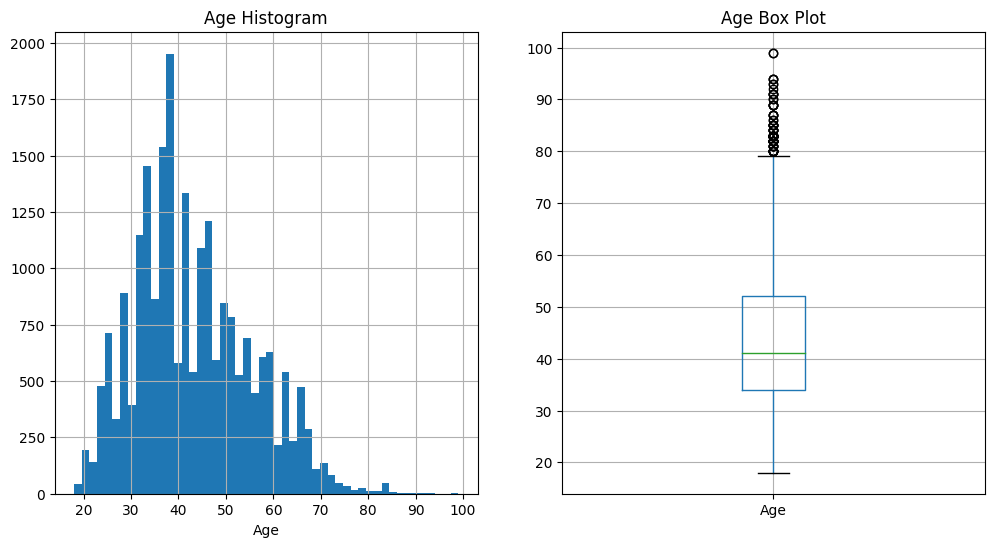

count   22315.000
mean        2.521
std         5.653
min         0.000
5%          0.000
10%         0.000
20%         0.000
30%         0.000
40%         0.000
50%         1.000
60%         1.000
70%         2.000
80%         3.000
90%         7.000
95%        11.000
99%        26.000
max       117.000
Name: Positive Feedback Count, dtype: float64


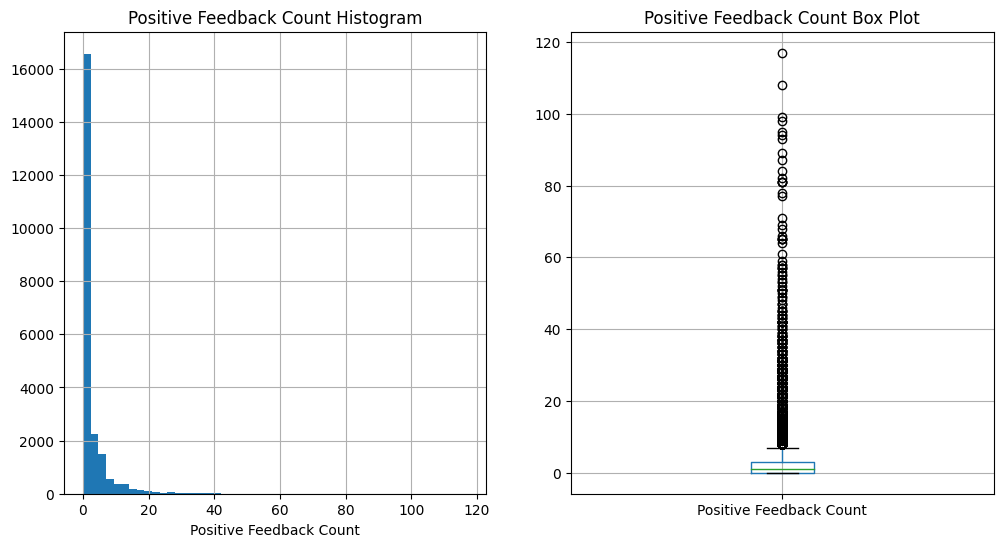

In [11]:
# NUMERİK DEĞİŞKENLERİN ANALİZİ
def num_summary(dataframe, numerical_col, plot=False):
    # Sayısal değişkenlerin özet istatistiklerini yazdır
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        # Histogram çiz
        plt.figure(figsize=(12, 6))

        plt.subplot(1, 2, 1)  # Birinci grafiği çiz
        dataframe[numerical_col].hist(bins=50)
        plt.xlabel(numerical_col)
        plt.title(f"{numerical_col} Histogram")

        # Box plot çiz
        plt.subplot(1, 2, 2)  # İkinci grafiği çiz
        dataframe.boxplot(column=numerical_col)
        plt.title(f"{numerical_col} Box Plot")

        plt.show(block=True)

for col in num_cols:
    num_summary(df, col, plot=True)



# Eksik Değer Analizi

In [12]:
#  Eksik Değer Analizi
print("\nEksik Değer Analizi:")
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing_values / df.shape[0]) * 100
missing_df = pd.DataFrame({'Eksik Değer Sayısı': missing_values, 'Eksik Değer Oranı (%)': missing_percentage})
print(missing_df[missing_df['Eksik Değer Sayısı'] > 0])  # Eksik değer oranları



Eksik Değer Analizi:
                         Eksik Değer Sayısı  Eksik Değer Oranı (%)
Title                                  4748                 20.216
Review Text                            1952                  8.311
Department Name                        1193                  5.080
Recommended IND                        1187                  5.054
Unnamed: 0                             1173                  4.994
Positive Feedback Count                1171                  4.986
Age                                    1151                  4.901
Clothing ID                            1141                  4.858
Rating                                 1126                  4.794
Class Name                             1121                  4.773
Division Name                          1111                  4.730


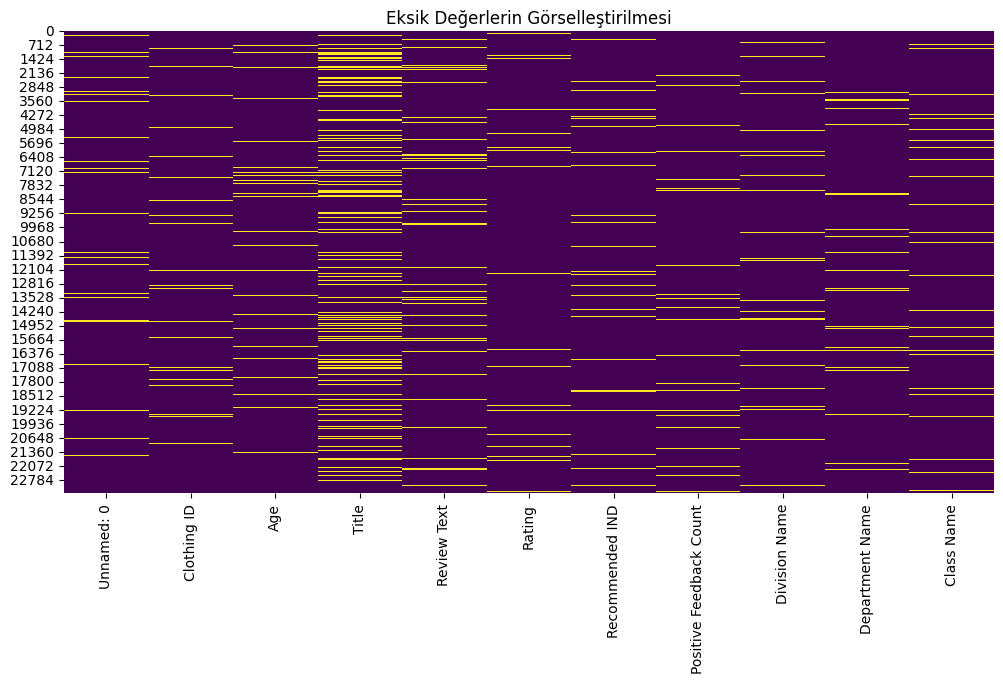

In [13]:

# Eksik değerleri görselleştir
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Eksik Değerlerin Görselleştirilmesi")
plt.show(block=True)


# Korelasyon matrisi

Sayısal sütunlar arasında anlamlı bir korelasyon görülmüyor, bu da değişkenlerin birbirinden bağımsız olduğunu gösteriyor. Özellikle Positive Feedback Count ve diğer sütunlar arasında çok düşük bir ilişki mevcut, bu yüzden her bir değişken ayrı analiz edilmeli.

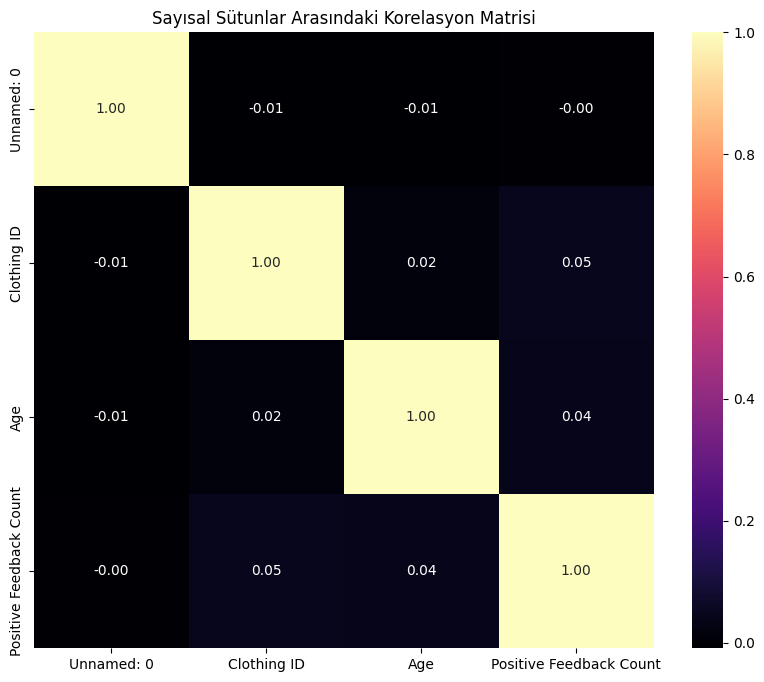

In [14]:
# Sadece sayısal sütunları seçme
numeric_df = df[num_cols]

# Korelasyon matrisi oluşturma ve görselleştirme
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="magma")
plt.title("Sayısal Sütunlar Arasındaki Korelasyon Matrisi")
plt.show(block=True)

corr = df[num_cols].corr()

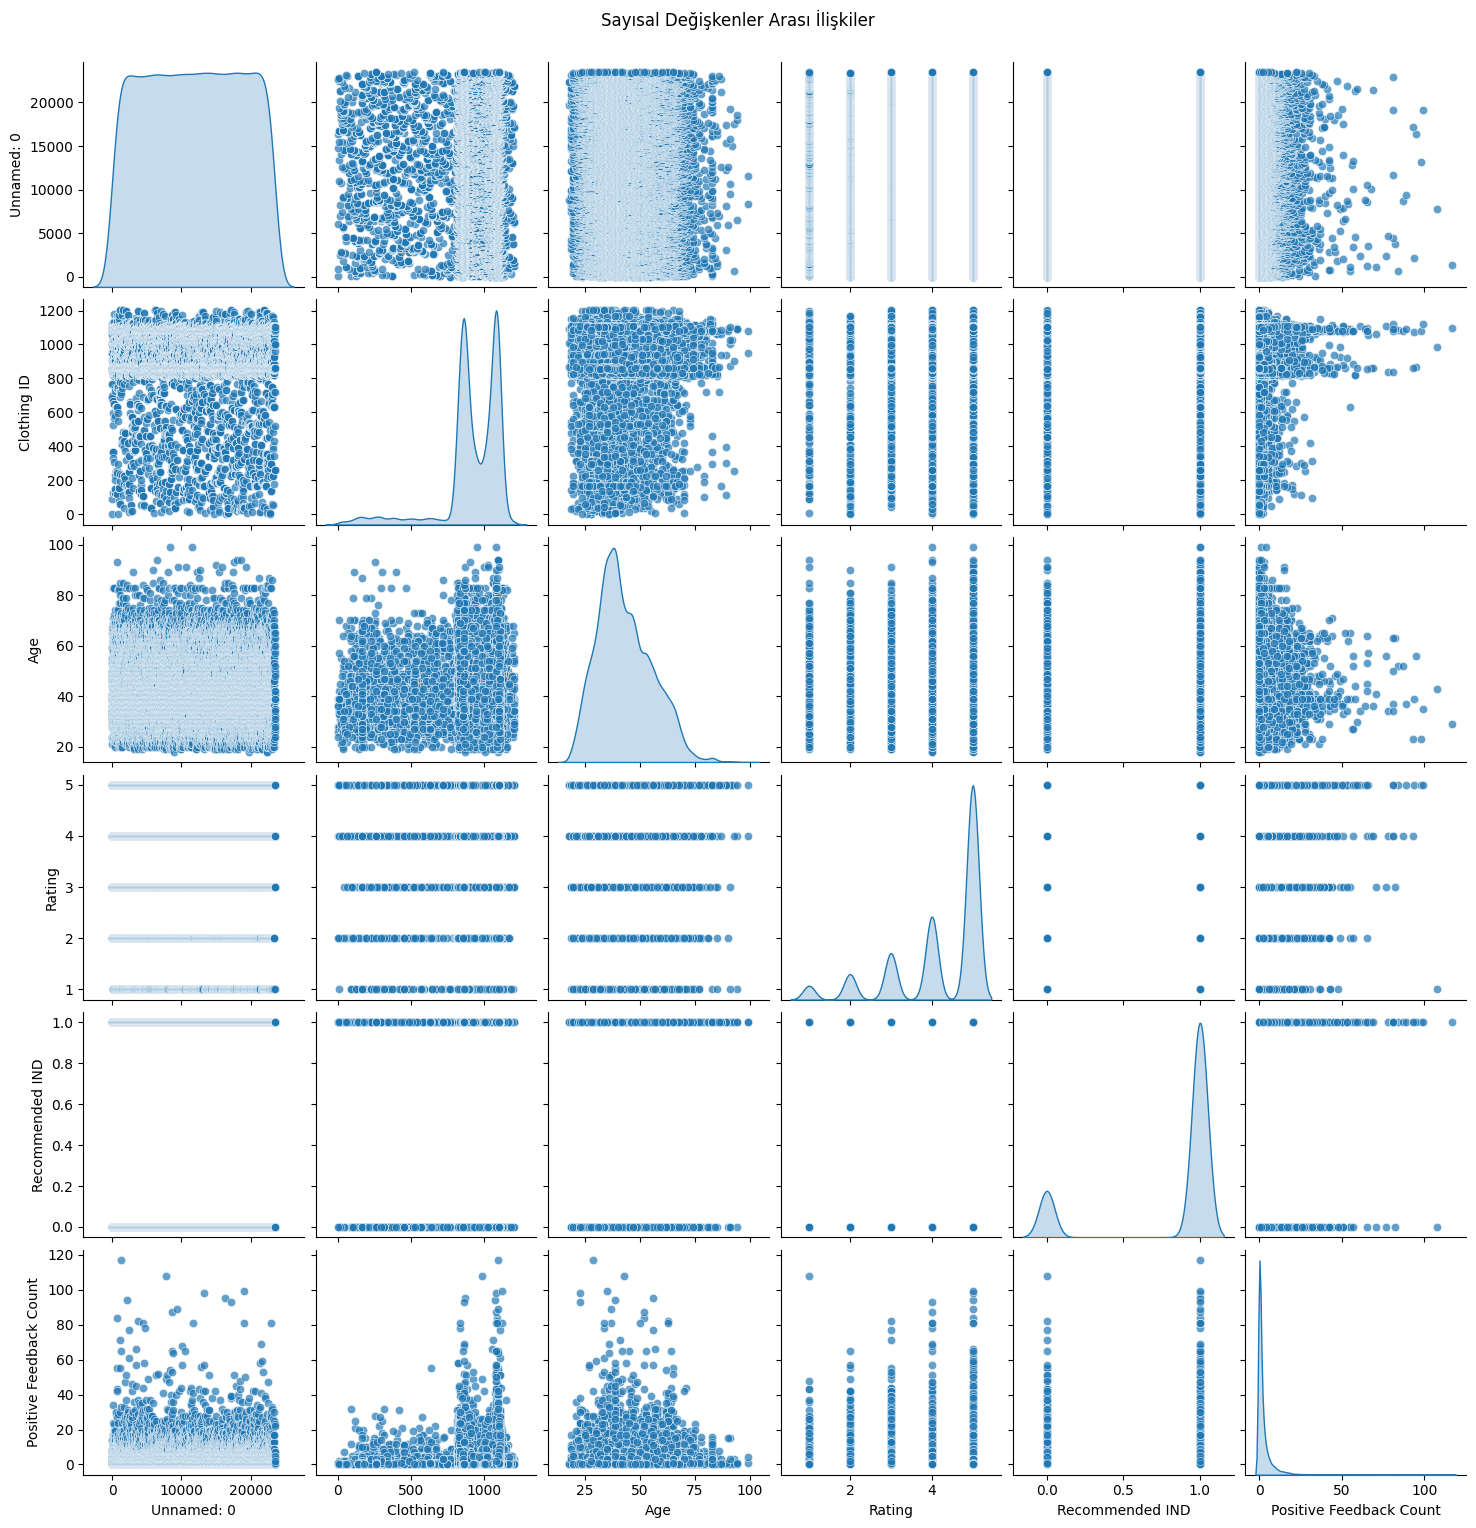

In [15]:
#  Sayısal Değişkenler Arası İlişkiler
# Çift değişkenli dağılım için scatter plot matrisi
sns.pairplot(df.select_dtypes(include=[np.number]), diag_kind='kde', plot_kws={'alpha':0.7})
plt.suptitle("Sayısal Değişkenler Arası İlişkiler", y=1.02)
plt.show(block=True)


In [16]:
# Kategorik ve Sayısal Değişkenler Arasındaki Kırılımlar
# pivot table ile kategorik değişkenlerin sayısal değerlere göre özet istatistikleri
for col in df.select_dtypes(include=['object']).columns:
    pivot = pd.pivot_table(df, index=col, values=df.select_dtypes(include=[np.number]).columns, aggfunc=['mean', 'median', 'std'])
    print(f"\n{col} Değişkenine Göre Sayısal Değişkenlerin Kırılımı:")
    print(pivot.head(10))



Title Değişkenine Göre Sayısal Değişkenlerin Kırılımı:
                                                    mean                                                                       median                                                                       std                                                                      
                                                     Age Clothing ID Positive Feedback Count Rating Recommended IND Unnamed: 0    Age Clothing ID Positive Feedback Count Rating Recommended IND Unnamed: 0 Age Clothing ID Positive Feedback Count Rating Recommended IND Unnamed: 0
Title                                                                                                                                                                                                                                                                                
"beach business"                                  35.000     828.000                   4.000  5.000           

# Aykırı Değerler

Aşağıdaki tablo, eksik verilerin olduğu satırların yanı sıra, bazı belirgin ürünlere ait pozitif geri bildirimlerin ve kullanıcı değerlendirmelerinin oldukça yüksek olduğunu gösteriyor.

In [17]:
#Aykırı Değerler

def outlier_thresholds(dataframe, variable, low_quantile=0.05, up_quantile=0.95):
    quantile_one = dataframe[variable].quantile(low_quantile)
    quantile_three = dataframe[variable].quantile(up_quantile)
    interquantile_range = quantile_three - quantile_one
    up_limit = quantile_three + 1.5 * interquantile_range
    low_limit = quantile_one - 1.5 * interquantile_range
    return low_limit, up_limit

In [18]:
# Aykırı değer Kontrolü
def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

for col in num_cols:
    if col != "price":
      print(col, check_outlier(df, col))


Unnamed: 0 False
Clothing ID False
Age False
Positive Feedback Count True


In [19]:
# Aykırı Değerlerin Kendilerine Erişmek
def grab_outliers(dataframe, col_name, index=False):
    low, up = outlier_thresholds(dataframe, col_name)

    if dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].shape[0] > 10:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].head())
    else:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))])

    if index:
        outlier_index = dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].index
        return outlier_index

for col in num_cols:
    print(col, grab_outliers(df, col))

Empty DataFrame
Columns: [Unnamed: 0, Clothing ID, Age, Title, Review Text, Rating, Recommended IND, Positive Feedback Count, Division Name, Department Name, Class Name]
Index: []
Unnamed: 0 None
Empty DataFrame
Columns: [Unnamed: 0, Clothing ID, Age, Title, Review Text, Rating, Recommended IND, Positive Feedback Count, Division Name, Department Name, Class Name]
Index: []
Clothing ID None
Empty DataFrame
Columns: [Unnamed: 0, Clothing ID, Age, Title, Review Text, Rating, Recommended IND, Positive Feedback Count, Division Name, Department Name, Class Name]
Index: []
Age None
     Unnamed: 0  Clothing ID    Age                              Title                                        Review Text  Rating  Recommended IND  Positive Feedback Count   Division Name Department Name Class Name
53       53.000      862.000 39.000         Flattering and comfortable  Very soft and comfortable. the shirt has an un...   5.000            1.000                   34.000         General            Tops

In [20]:
# Aykırı Değerlerin Baskılanması
def replace_with_thresholds(dataframe, variable):
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit


for col in num_cols:
    if col != "price":
        replace_with_thresholds(df,col)


for col in num_cols:
    if col != "price":
      print(col, check_outlier(df, col))


Unnamed: 0 False
Clothing ID False
Age False
Positive Feedback Count False


count   22313.000
mean    11762.736
std      6782.416
min         0.000
5%       1167.600
10%      2338.200
20%      4707.400
30%      7071.600
40%      9438.800
50%     11787.000
60%     14124.200
70%     16466.400
80%     18806.600
90%     21144.800
95%     22314.400
99%     23247.880
max     23485.000
Name: Unnamed: 0, dtype: float64


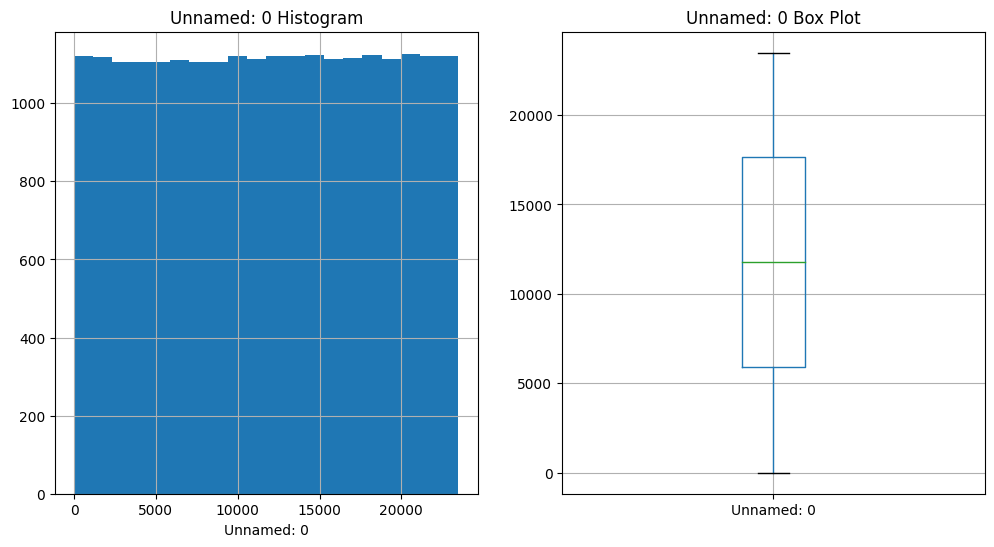

count   22345.000
mean      917.966
std       204.057
min         0.000
5%        412.200
10%       819.000
20%       839.000
30%       863.000
40%       876.000
50%       936.000
60%      1020.000
70%      1065.000
80%      1081.000
90%      1094.000
95%      1104.000
99%      1133.000
max      1205.000
Name: Clothing ID, dtype: float64


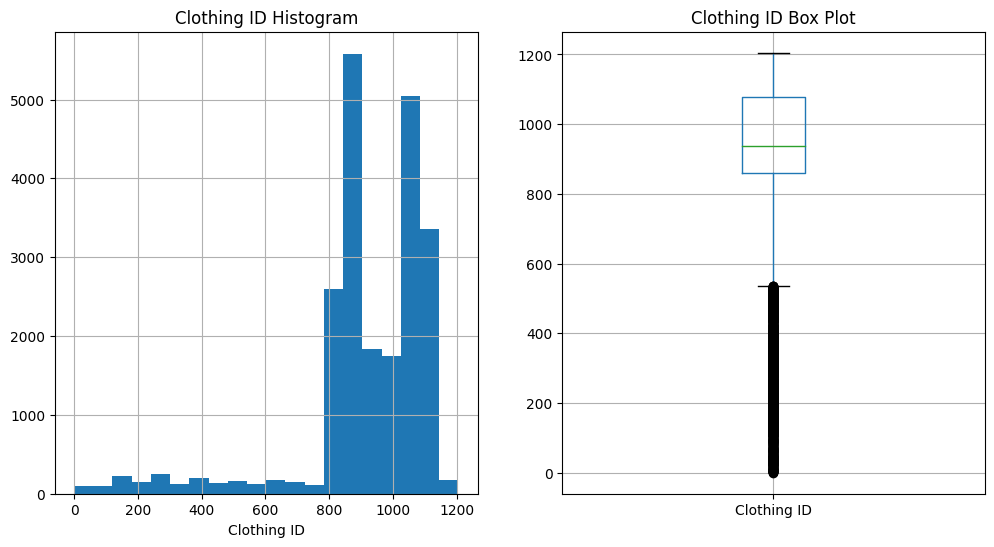

count   22335.000
mean       43.189
std        12.285
min        18.000
5%         25.000
10%        28.000
20%        33.000
30%        36.000
40%        39.000
50%        41.000
60%        45.000
70%        49.000
80%        54.000
90%        61.000
95%        65.000
99%        74.000
max        99.000
Name: Age, dtype: float64


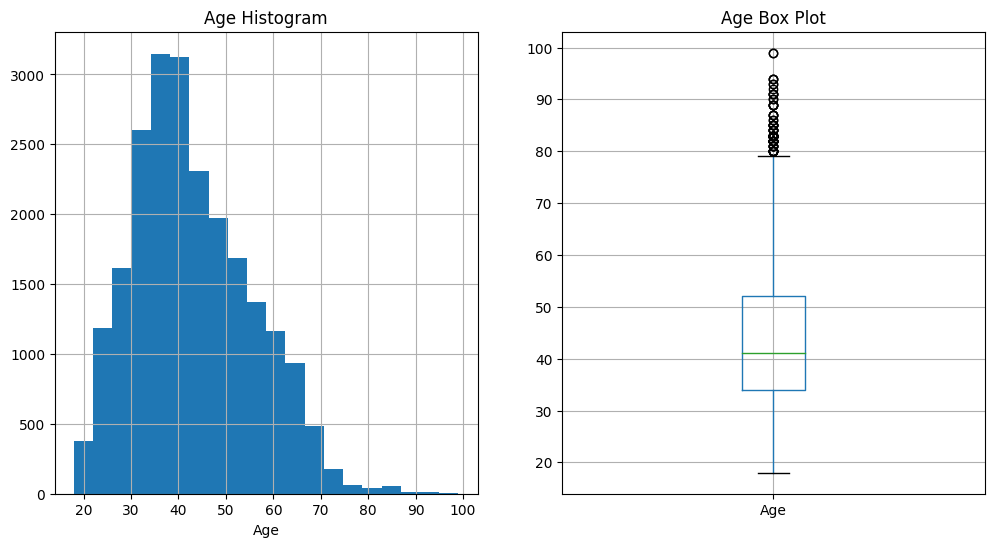

count   22315.000
mean        2.389
std         4.527
min         0.000
5%          0.000
10%         0.000
20%         0.000
30%         0.000
40%         0.000
50%         1.000
60%         1.000
70%         2.000
80%         3.000
90%         7.000
95%        11.000
99%        26.000
max        27.500
Name: Positive Feedback Count, dtype: float64


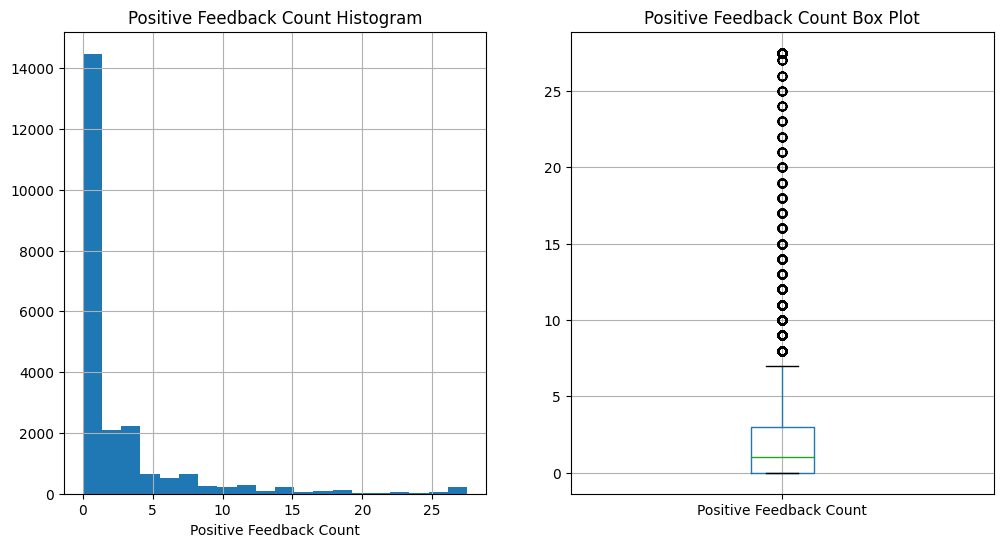

In [21]:

# NUMERİK DEĞİŞKENLERİN ANALİZİ
def num_summary(dataframe, numerical_col, plot=False):
    # Sayısal değişkenlerin özet istatistiklerini yazdır
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        # Histogram çiz
        plt.figure(figsize=(12, 6))

        plt.subplot(1, 2, 1)  # Birinci grafiği çiz
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(f"{numerical_col} Histogram")

        # Box plot çiz
        plt.subplot(1, 2, 2)  # İkinci grafiği çiz
        dataframe.boxplot(column=numerical_col)
        plt.title(f"{numerical_col} Box Plot")

        plt.show(block=True)

for col in num_cols:
    num_summary(df, col, plot=True)


# Eksik Değer Analizi

In [22]:
#  Eksik Değer Analizi
print("\nEksik Değer Analizi:")
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing_values / df.shape[0]) * 100
missing_df = pd.DataFrame({'Eksik Değer Sayısı': missing_values, 'Eksik Değer Oranı (%)': missing_percentage})
print(missing_df[missing_df['Eksik Değer Sayısı'] > 0])  # Eksik değer oranları



Eksik Değer Analizi:
                         Eksik Değer Sayısı  Eksik Değer Oranı (%)
Title                                  4748                 20.216
Review Text                            1952                  8.311
Department Name                        1193                  5.080
Recommended IND                        1187                  5.054
Unnamed: 0                             1173                  4.994
Positive Feedback Count                1171                  4.986
Age                                    1151                  4.901
Clothing ID                            1141                  4.858
Rating                                 1126                  4.794
Class Name                             1121                  4.773
Division Name                          1111                  4.730


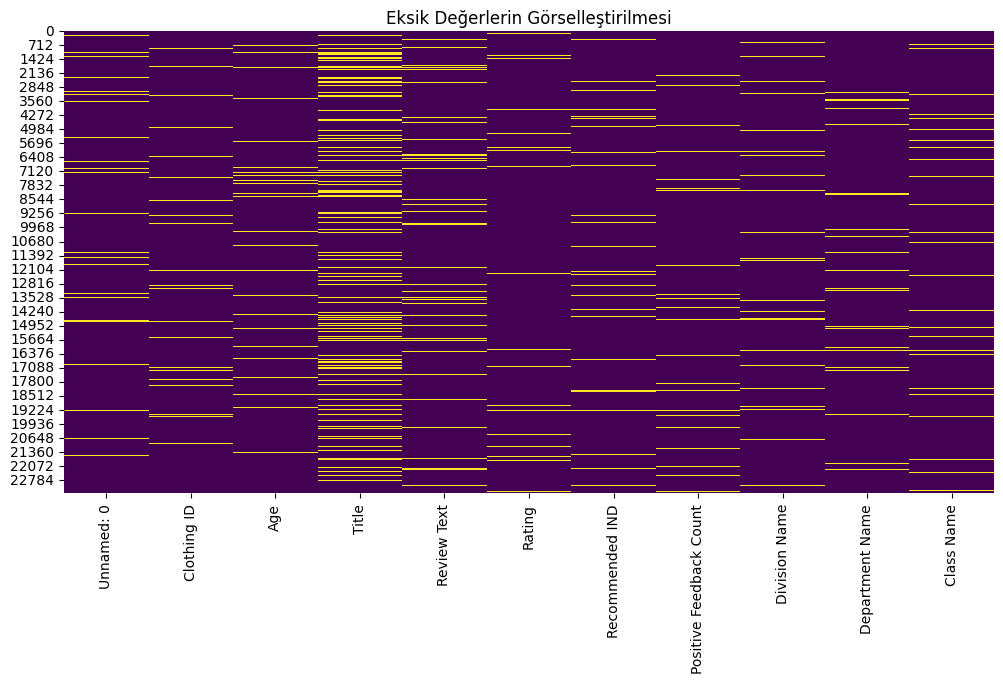

In [23]:

# Eksik değerleri görselleştir
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Eksik Değerlerin Görselleştirilmesi")
plt.show(block=True)


# Eksik Değerleri Doldurma

Class Name, Department Name ve Division Name gibi kategorik değişkenler kırılımda mod ile, sayısal değişkenler ise ortalama, medyan veya KNN imputation yöntemiyle dolduruluyor. Eğer tüm bu işlemler sonucunda hala eksik değerler varsa, kalan eksik veriye sahip satırlar veri setinden siliniyor.

In [24]:
# Clothing ID sütunundaki eksik değerleri 0 ile doldurma
df['Clothing ID'] = df['Clothing ID'].fillna(0)


In [25]:
#"Unknown" gibi bir placeholder kullandık
df['Title'].fillna("Unknown", inplace=True)


In [26]:
#"No Review" gibi bir placeholder kullandık
df['Review Text'].fillna("No Review", inplace=True)


In [27]:
#Eksik değerler sıfır (0) ile dolduruldu.
df['Unnamed: 0'].fillna(0, inplace=True)


In [28]:
#Gruplandırılmış(Department Name Kırılımında) mod kullanıldı
df['Class Name'] = df['Class Name'].fillna(
    df.groupby('Department Name')['Class Name'].transform(lambda x: x.mode()[0] if not x.mode().empty else "Unknown")
)
# Eğer hala eksik değer varsa Division Name bazında doldurma
if df['Class Name'].isnull().sum() != 0:
    df['Class Name'] = df['Class Name'].fillna(
        df.groupby('Division Name')['Class Name'].transform(lambda x: x.mode()[0] if not x.mode().empty else "Unknown")
    )


In [29]:
df['Department Name'] = df['Department Name'].fillna(
    df.groupby('Class Name')['Department Name'].transform(lambda x: x.mode()[0] if not x.mode().empty else "Unknown")
)
# Eğer hala eksik değer varsa Division Name bazında doldurma
if df['Department Name'].isnull().sum() != 0:
    df['Department Name'] = df['Department Name'].fillna(
        df.groupby('Division Name')['Department Name'].transform(lambda x: x.mode()[0] if not x.mode().empty else "Unknown")
    )

In [30]:
# Division Name eksik değerlerini Department Name ve Class Name'e göre gruplandırılmış mod ile doldurma
df['Division Name'] = df['Division Name'].fillna(
    df.groupby(['Department Name', 'Class Name'])['Division Name'].transform(
        lambda x: x.mode()[0] if not x.mode().empty else "Unknown"
    )
)

# Eğer hala eksik değer varsa sadece Department Name'e göre doldurma
if df['Division Name'].isnull().sum() != 0:
    df['Division Name'] = df['Division Name'].fillna(
        df.groupby('Department Name')['Division Name'].transform(
            lambda x: x.mode()[0] if not x.mode().empty else "Unknown"
        )
    )

In [31]:
# Positive Feedback Count eksik değerlerini Department Name ve Class Name'e göre gruplandırılmış ortalama değerlerle doldurma
df['Positive Feedback Count'] = df['Positive Feedback Count'].fillna(
    df.groupby(['Department Name', 'Class Name'])['Positive Feedback Count'].transform('mean')
)

In [32]:
# Eğer hala eksik değer varsa Class Name bazında doldur
if df['Positive Feedback Count'].isnull().sum() != 0:
    df['Positive Feedback Count'] = df['Positive Feedback Count'].fillna(
        df.groupby(['Division Name'])['Positive Feedback Count'].transform('mean')
    )


In [33]:
# Age sütunundaki eksik değerleri Class Name'e göre gruplandırılmış medyan ile doldurma
df['Age'] = df['Age'].fillna(
    df.groupby('Class Name')['Age'].transform('median')
)


In [34]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler

# Rating sütunu için KNN ile eksik değer doldurma

# Rating sütununun ölçeklendirilmesi
scaler = RobustScaler()
rating_scaled = pd.DataFrame(scaler.fit_transform(df[['Rating']]), columns=['Rating'])

# KNN ile eksik değer doldurma
imputer = KNNImputer(n_neighbors=5)
rating_imputed = pd.DataFrame(imputer.fit_transform(rating_scaled), columns=['Rating'])

# Orijinal ölçeğe geri döndürme
rating_final = pd.DataFrame(scaler.inverse_transform(rating_imputed), columns=['Rating'])

# Orijinal veri setinde Rating sütununu güncelleme
df['Rating'] = rating_final['Rating']

# Eksik değerlerin kontrolü
rating_missing_after_knn = df['Rating'].isnull().sum()

rating_missing_after_knn

0

In [35]:

# Class Name ve Rating kırılımında mod ile doldurma
df['Recommended IND'] = df['Recommended IND'].fillna(
    df.groupby(['Class Name', 'Rating'])['Recommended IND'].transform(
        lambda x: x.mode()[0] if not x.mode().empty else 0
    )
)

# Hala eksik varsa genel mod ile doldur
if df['Recommended IND'].isnull().sum() > 0:
    df['Recommended IND'].fillna(df['Recommended IND'].mode()[0], inplace=True)



In [36]:
df.isnull().sum()

Unnamed: 0                  0
Clothing ID                 0
Age                         0
Title                       0
Review Text                 0
Rating                      0
Recommended IND             0
Positive Feedback Count     1
Division Name              17
Department Name            17
Class Name                 17
dtype: int64

In [37]:
# Eğer hala eksik değer varsa bu satırları sil
if df.isnull().sum().sum() > 0:
    df = df.dropna()

df.isnull().sum()

Unnamed: 0                 0
Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64

# Clothing ID ve Unnamed: 0 sütunlarını çıkarma

#Duygu analizi yapmayı tercih edersem; Duygu analizi için çıkarılması gereken sütunlar Clothing ID, Unnamed: 0 ve Positive Feedback Count'tur, çünkü metin içeriğiyle ilişkili değillerdir.

In [38]:
df = df.drop(columns=['Clothing ID', 'Unnamed: 0'], errors='ignore')
df.head()

,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,33.000,Unknown,Absolutely wonderful - silky and sexy and comf...,4.000,1.000,0.000,Initmates,Intimate,Intimates
1,34.000,Unknown,Love this dress! it's sooo pretty. i happene...,5.000,1.000,4.000,General,Dresses,Dresses
2,60.000,Some major design flaws,I had such high hopes for this dress and reall...,3.000,0.000,0.000,General,Dresses,Dresses
3,50.000,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5.000,1.000,2.334,General Petite,Bottoms,Pants
4,47.000,Flattering shirt,This shirt is very flattering to all due to th...,5.000,1.000,6.000,General,Tops,Blouses
